# Will this order arrive late?

Late deliveries are the single biggest driver of bad reviews on the Brazilian Olist marketplace (in the [Power BI report](https://github.com/kagap/powerbi/tree/main/OlistEcommerce_BrazilianMarketplace) late orders score about 1.7 stars lower). If an order can be flagged as risky *before* it ships, operations can step in: pick a faster carrier, warn the customer, or chase the seller.

This notebook builds a model that estimates the probability that an order is delivered after its estimated delivery date, using only information available when the order is placed or approved.

**Data:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle). Point `OLIST_DIR` at the folder with the extracted CSV files.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

DATA_DIR = Path(os.environ.get("OLIST_DIR", "olist_data"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})

## 1. Load the data

In [2]:
dates = ["order_purchase_timestamp", "order_approved_at", "order_delivered_customer_date",
         "order_estimated_delivery_date"]
orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv", parse_dates=dates)
items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv", parse_dates=["shipping_limit_date"])
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
geo = pd.read_csv(DATA_DIR / "olist_geolocation_dataset.csv")

orders.order_status.value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## 2. The target

An order is **late** when it reaches the customer after the estimated delivery date shown at checkout. Only delivered orders have an outcome, so cancelled and still-in-transit orders are dropped.

96,470 delivered orders, 8.1% arrived late


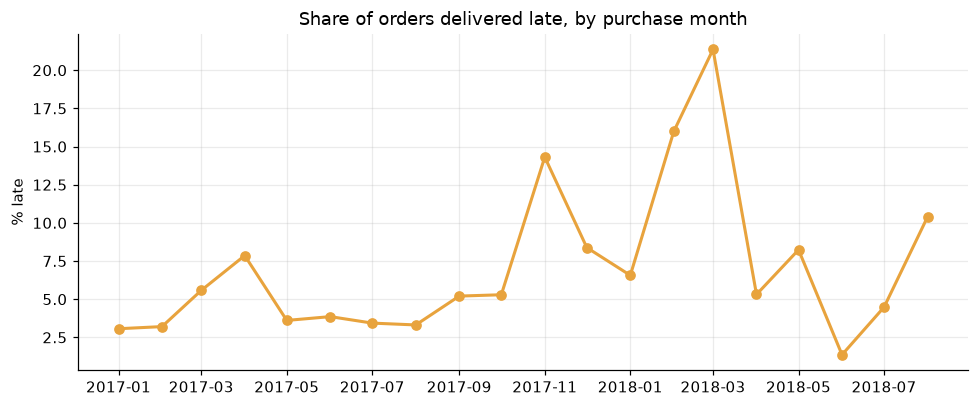

In [3]:
df = orders[orders.order_status == "delivered"].dropna(subset=["order_delivered_customer_date"]).copy()
df["late"] = (df.order_delivered_customer_date > df.order_estimated_delivery_date).astype(int)
print(f"{len(df):,} delivered orders, {df.late.mean():.1%} arrived late")

monthly = (df.set_index("order_purchase_timestamp").late.resample("MS")
             .agg(["mean", "size"]).query("size >= 300"))

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(monthly.index, monthly["mean"] * 100, marker="o", color=AMBER, linewidth=2)
ax.set_title("Share of orders delivered late, by purchase month")
ax.set_ylabel("% late")
fig.tight_layout()
plt.show()

The late rate is not stable over time: it spikes in a few months and then drops back. That matters for how the model has to be validated (see section 4).

## 3. Features

Everything below is known when the order is placed or approved. Nothing from delivery is used.

- **Order**: items, sellers, price, freight, weight, volume, purchase hour / weekday / month
- **Route**: customer and seller state, product category, and the great-circle **distance** between the seller's and the customer's postcode
- **Promise**: how many days the checkout estimate leaves, and how tight that is compared to a typical estimate on the same route
- **Seller handling**: the deadline given to the seller to hand over the parcel, and how long approval took
- **Seller track record**: share of that seller's earlier orders that were late, using only orders already *delivered* before this purchase (no peeking into the future)

In [4]:
g = items.merge(products, on="product_id", how="left")
g["volume"] = g.product_length_cm * g.product_height_cm * g.product_width_cm
agg = g.groupby("order_id").agg(
    n_items=("order_item_id", "count"), n_sellers=("seller_id", "nunique"),
    price=("price", "sum"), freight=("freight_value", "sum"),
    weight=("product_weight_g", "sum"), volume=("volume", "sum"),
    category=("product_category_name", "first"), seller_id=("seller_id", "first"),
    shipping_limit=("shipping_limit_date", "min"),
).reset_index()

df = (df.merge(agg, on="order_id")
        .merge(customers[["customer_id", "customer_state", "customer_zip_code_prefix"]], on="customer_id", how="left")
        .merge(sellers[["seller_id", "seller_state", "seller_zip_code_prefix"]], on="seller_id", how="left"))

# one coordinate per postcode prefix, then the distance seller -> customer
zip_xy = geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]].mean()
df = (df.merge(zip_xy.add_prefix("c_"), left_on="customer_zip_code_prefix", right_index=True, how="left")
        .merge(zip_xy.add_prefix("s_"), left_on="seller_zip_code_prefix", right_index=True, how="left"))

def haversine_km(lat1, lon1, lat2, lon2):
    p1, p2 = np.radians(lat1), np.radians(lat2)
    a = np.sin((p2 - p1) / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(np.radians(lon2 - lon1) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine_km(df.s_geolocation_lat, df.s_geolocation_lng,
                                  df.c_geolocation_lat, df.c_geolocation_lng)
ts = df.order_purchase_timestamp
df["est_days"] = (df.order_estimated_delivery_date - ts).dt.total_seconds() / 86400
df["handling_days"] = (df.shipping_limit - ts).dt.total_seconds() / 86400
df["approval_hours"] = (df.order_approved_at - ts).dt.total_seconds() / 3600
df["month"], df["dow"], df["hour"] = ts.dt.month, ts.dt.dayofweek, ts.dt.hour
df["same_state"] = (df.customer_state == df.seller_state).astype(int)
df["freight_ratio"] = df.freight / (df.price + 1)
df["km_per_est_day"] = df.distance_km / df.est_days
df["route"] = df.seller_state.fillna("?") + ">" + df.customer_state.fillna("?")

# seller track record: only orders already delivered before this purchase
PRIOR, SMOOTH = df.late.mean(), 20
df["seller_orders_before"] = 0.0
df["seller_late_rate_before"] = PRIOR
for _, grp in df.groupby("seller_id"):
    d = grp.sort_values("order_delivered_customer_date")
    cum_late = np.concatenate([[0], np.cumsum(d.late.values)])
    idx = np.searchsorted(d.order_delivered_customer_date.values, grp.order_purchase_timestamp.values)
    df.loc[grp.index, "seller_orders_before"] = idx
    df.loc[grp.index, "seller_late_rate_before"] = (cum_late[idx] + SMOOTH * PRIOR) / (idx + SMOOTH)

df.shape

(96470, 39)

## 4. Validation: train on the past, test on the future

A random split would let the model learn from orders placed *after* the ones it is tested on, which is not how it would be used. Instead the first 80% of orders by purchase date are used for training and the last 20% for testing. The "typical estimate on this route" is also computed from the training period only.

In [5]:
df = df.sort_values("order_purchase_timestamp").reset_index(drop=True)
cut = df.order_purchase_timestamp.quantile(0.8)
train, test = df[df.order_purchase_timestamp <= cut].copy(), df[df.order_purchase_timestamp > cut].copy()

route_median = train.groupby("route").est_days.median()
for part in (train, test):
    part["est_vs_route"] = part.est_days - part.route.map(route_median).fillna(train.est_days.median())

NUM = ["n_items", "n_sellers", "price", "freight", "weight", "volume", "distance_km", "est_days",
       "month", "dow", "hour", "same_state", "freight_ratio", "handling_days", "approval_hours",
       "km_per_est_day", "est_vs_route", "seller_orders_before", "seller_late_rate_before"]
CAT = ["customer_state", "seller_state", "category"]
X_tr, y_tr, X_te, y_te = train[NUM + CAT], train.late, test[NUM + CAT], test.late

print(f"train: {len(train):,} orders up to {cut:%Y-%m-%d}, {y_tr.mean():.1%} late")
print(f"test:  {len(test):,} orders after that date, {y_te.mean():.1%} late")

train: 77,176 orders up to 2018-05-26, 8.8% late
test:  19,294 orders after that date, 5.3% late


## 5. Two models

A **logistic regression** is the baseline: simple, fast and easy to explain. A **gradient boosting** model can capture interactions (for example a long distance combined with a short estimate).

In [6]:
linear = make_pipeline(
    ColumnTransformer([
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=50), CAT)]),
    LogisticRegression(max_iter=1000, class_weight="balanced"))

boosted = make_pipeline(
    ColumnTransformer([
        ("num", "passthrough", NUM),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CAT)]),
    HistGradientBoostingClassifier(
        categorical_features=list(range(len(NUM), len(NUM) + len(CAT))),
        learning_rate=0.04, max_iter=250, max_depth=5, min_samples_leaf=80,
        l2_regularization=2.0, random_state=0))

models = {"Logistic regression": linear, "Gradient boosting": boosted}
scores = {}
for name, model in models.items():
    model.fit(X_tr, y_tr)
    scores[name] = model.predict_proba(X_te)[:, 1]

pd.DataFrame({
    "ROC AUC": {n: roc_auc_score(y_te, p) for n, p in scores.items()},
    "PR AUC": {n: average_precision_score(y_te, p) for n, p in scores.items()},
}).round(3).assign(**{"PR AUC if guessing": round(y_te.mean(), 3)})

,ROC AUC,PR AUC,PR AUC if guessing
Logistic regression,0.706,0.115,0.053
Gradient boosting,0.717,0.113,0.053


**How to read this.** ROC AUC is the chance that a randomly chosen late order gets a higher risk score than a randomly chosen on-time one (0.5 = coin flip, 1.0 = perfect). With only about 5-8% of orders late, the precision-recall AUC is the harsher test, and the last column shows what pure guessing would score.

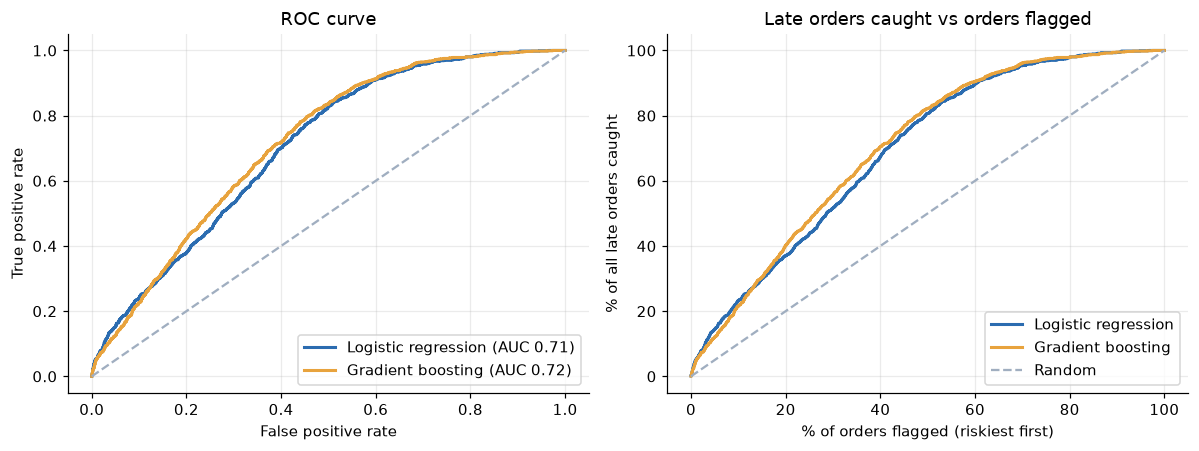

In [7]:
def cumulative_gain(y, p):
    order = np.argsort(-p)
    caught = np.cumsum(y.values[order]) / y.sum()
    return np.arange(1, len(y) + 1) / len(y), caught

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
colors = {"Logistic regression": BLUE, "Gradient boosting": AMBER}
for name, p in scores.items():
    fpr, tpr, _ = roc_curve(y_te, p)
    ax1.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_te, p):.2f})", color=colors[name], linewidth=2)
    share, caught = cumulative_gain(y_te, p)
    ax2.plot(share * 100, caught * 100, label=name, color=colors[name], linewidth=2)
ax1.plot([0, 1], [0, 1], "--", color=GREY)
ax1.set(title="ROC curve", xlabel="False positive rate", ylabel="True positive rate")
ax1.legend(loc="lower right")
ax2.plot([0, 100], [0, 100], "--", color=GREY, label="Random")
ax2.set(title="Late orders caught vs orders flagged", xlabel="% of orders flagged (riskiest first)",
        ylabel="% of all late orders caught")
ax2.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 6. What would it mean in practice?

A model is only useful if it changes a decision. Suppose operations can only act on a limited share of orders, say the riskiest 10%, 20% or 30%. How many late deliveries would that cover?

In [8]:
best = scores["Gradient boosting"]
rows = []
for frac in (0.05, 0.10, 0.20, 0.30):
    k = int(len(y_te) * frac)
    top = np.argsort(-best)[:k]
    caught = y_te.values[top].sum()
    rows.append({"orders flagged": f"top {frac:.0%}",
                 "late orders caught": f"{caught / y_te.sum():.0%}",
                 "flagged that really are late": f"{caught / k:.0%}",
                 "vs. random": f"{(caught / y_te.sum()) / frac:.1f}x"})
pd.DataFrame(rows).set_index("orders flagged")

,late orders caught,flagged that really are late,vs. random
orders flagged,,,
top 5%,12%,13%,2.4x
top 10%,22%,11%,2.2x
top 20%,40%,11%,2.0x
top 30%,56%,10%,1.9x


## 7. What drives the risk?

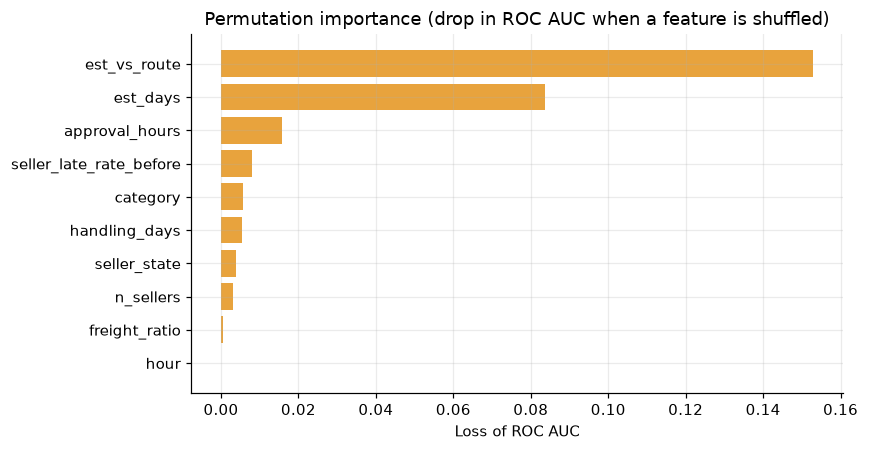

In [9]:
rng = np.random.RandomState(0)
sample = rng.choice(len(X_te), size=min(6000, len(X_te)), replace=False)
result = permutation_importance(boosted, X_te.iloc[sample], y_te.iloc[sample], scoring="roc_auc",
                                n_repeats=4, random_state=0, n_jobs=1)
importance = (pd.Series(result.importances_mean, index=NUM + CAT).sort_values().tail(10))

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(importance.index, importance.values, color=AMBER)
ax.set_title("Permutation importance (drop in ROC AUC when a feature is shuffled)")
ax.set_xlabel("Loss of ROC AUC")
fig.tight_layout()
plt.show()

## 8. Takeaways

- **Lateness is only moderately predictable at order time.** Both models reach a ROC AUC of about 0.71-0.72, and the precision-recall AUC (about 0.11) is roughly twice what guessing would give. The gradient boosting model is only slightly better than the logistic baseline, so the extra complexity buys little.
- **It is useful if the action is cheap.** Flagging the riskiest 20% of orders catches about 40% of all late deliveries, twice as many as picking at random. But only about 1 in 9 flagged orders is really late, so a proactive message to the customer pays off, while an expensive intervention would not.
- **The delivery promise is the main signal.** The two strongest features by far are how long the checkout estimate is and how it compares with a typical estimate on the same route: unusually tight promises get missed. The seller track record, distance and product size matter much less once the promise is known.
- **The late rate is driven by time more than by order attributes.** It spikes in Nov 2017 and in Feb-Mar 2018 and falls back afterwards, and the model is trained on a period with 8.8% late orders but tested on a calmer one with 5.3%. That shift caps the achievable score, and it is why the validation is chronological instead of random.
- **Next steps.** Features about the network rather than the order should help most: daily order volume as a congestion signal, the carrier, holidays and promotions. Predictions would also need to be recalibrated regularly, because the baseline late rate moves from month to month.